# 03 - Attention interpretation

Train `MaldiMLPClassifier` with the default sigmoid-gated attention on real MALDI-TOF spectra and visualize the learned per-unit gates.

Uses the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)); see notebook 01 for caching details.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from notebooks._demo import binary_labels, load_maldi_kleb_ai

demo = load_maldi_kleb_ai(antibiotic='Amikacin', verbose=True)
X, y = binary_labels(demo)
print(f'X: {X.shape} | prevalence(R): {y.mean():.2%}')

Processing spectra:   0%|          | 0/743 [00:00<?, ?spectrum/s]

X: (741, 6000) | prevalence(R): 49.80%


In [2]:
import numpy as np
from maldideepkit import MaldiMLPClassifier

clf = MaldiMLPClassifier(epochs=30, hidden_dim=256, random_state=0).fit(X, y)

# Inspect a balanced subset: first 10 susceptible + first 10 resistant samples.
sus = X.loc[y == 0].head(10)
res = X.loc[y == 1].head(10)
X_view = np.vstack([sus.to_numpy(), res.to_numpy()])
labels_view = np.array(['S'] * len(sus) + ['R'] * len(res))

weights = clf.get_attention_weights(X_view)
print('weights shape:', weights.shape)

weights shape: (20, 256)


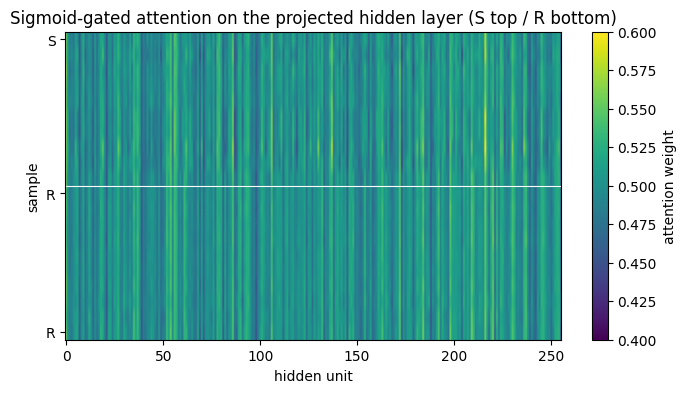

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(weights, aspect='auto', cmap='viridis', vmin=0.4, vmax=0.6)
ax.set_xlabel('hidden unit')
ax.set_ylabel('sample')
ax.set_yticks([0, len(sus), len(sus) + len(res) - 1])
ax.set_yticklabels([labels_view[0], labels_view[len(sus)], labels_view[-1]])
ax.axhline(len(sus) - 0.5, color='white', lw=0.8)
fig.colorbar(im, ax=ax, label='attention weight')
ax.set_title('Sigmoid-gated attention on the projected hidden layer (S top / R bottom)')
plt.show()

The attention vector is computed on the *projected* hidden representation, not on the raw m/z bins, so the column index is a learned feature axis rather than a Dalton coordinate. Units that stay close to 1 across samples are unconditionally retained; units near 0 are gated off. The variance across samples - and especially across the S/R split - points at the units that are class-discriminative.

Setting `use_attention=False` recovers a plain MLP of the same depth and disables `get_attention_weights`.